# Protein-centered prior-knowledge investigation (OmniPath)

This notebook demonstrates one concrete workflow:

1. Pick a seed protein (by `entity_id` or text query)
2. Retrieve all interactions involving that protein
3. Retrieve all partner entities
4. Analyze partner GO/HPO annotation distributions
5. Build exploratory graphs

---

## Other interesting investigations you can run

- **Phenotype-focused neighborhoods**: Start from an HPO term (e.g. seizure) and compare partner profiles across descendant terms.
- **Compartment-specific signaling**: Restrict to GO compartments (nucleus/cytosol/membrane) and compare sign/direction distributions.
- **Source robustness**: Build the same network using only one source (SIGNOR/Reactome/IntAct) vs consensus.
- **Mechanism layering**: Overlay interaction terms (phosphorylation, transcriptional regulation, etc.) on top of protein neighborhoods.
- **Association context**: For the same partner set, inspect complexes/reactions/pathways where partners are members.


## Setup

In [1]:
import io
import os
import re
from pathlib import Path

import requests
import polars as pl
import networkx as nx
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (10, 7)
plt.rcParams['figure.dpi'] = 120


In [2]:
def find_env_value(key: str, start: Path | None = None) -> str | None:
    start = start or Path.cwd()
    for p in [start, *start.parents]:
        env = p / '.env'
        if env.exists():
            txt = env.read_text()
            m = re.search(rf'{key}=\"([^\"]+)\"', txt)
            if m:
                return m.group(1)
    return None

ONTOLOGY_API = os.getenv('ONTOLOGY_API', 'http://localhost:8081')
MEILI_API = os.getenv('MEILI_API', 'http://localhost:7700')
MEILI_KEY = os.getenv('MEILISEARCH_API_KEY') or find_env_value('MEILISEARCH_API_KEY')

assert MEILI_KEY, 'Could not find MEILISEARCH_API_KEY in env or .env file'
MEILI_HEADERS = {'Authorization': f'Bearer {MEILI_KEY}', 'Content-Type': 'application/json'}

print('Ontology API:', ONTOLOGY_API)
print('Meilisearch API:', MEILI_API)


Ontology API: http://localhost:8081
Meilisearch API: http://localhost:7700


## Helper functions

In [3]:
def post_export(resource: str, payload: dict) -> pl.DataFrame:
    """Call api-service export endpoint and parse parquet response into Polars DataFrame."""
    url = f'{ONTOLOGY_API}/exports/{resource}/parquet'
    r = requests.post(url, json=payload, timeout=300)
    r.raise_for_status()
    row_count = r.headers.get('X-Export-Row-Count', '?')
    print(f'[{resource}] exported rows:', row_count)
    return pl.read_parquet(io.BytesIO(r.content))

def meili_search_entities(query: str, limit: int = 20, filter_string: str | None = None) -> list[dict]:
    payload = {
        'q': query,
        'limit': limit,
        'attributesToRetrieve': ['entity_id','entity_type','names','gene_symbols','identifiers','ncbi_tax_id','sources']
    }
    if filter_string:
        payload['filter'] = filter_string
    r = requests.post(f'{MEILI_API}/indexes/search_entities/search', headers=MEILI_HEADERS, json=payload, timeout=120)
    r.raise_for_status()
    return r.json().get('hits', [])

def primary_name(row: dict) -> str:
    names = row.get('names') or []
    if names:
        return names[0]
    gs = row.get('gene_symbols') or []
    if gs:
        return gs[0]
    return str(row.get('entity_id'))


## 1) Choose seed protein

Set either:
- `seed_entity_id` directly, or
- `seed_query` and pick one candidate.

In [4]:
seed_entity_id = None  # e.g. 3728
seed_query = 'MAPK1'
species_filter = 'ncbi_tax_id = "9606"'

if seed_entity_id is None:
    candidates = meili_search_entities(seed_query, limit=10, filter_string=species_filter)
    print(f'Found {len(candidates)} candidates for query={seed_query!r}')
    for i, c in enumerate(candidates):
        print(i, c.get('entity_id'), c.get('entity_type'), primary_name(c), (c.get('gene_symbols') or [])[:3])
    assert candidates, 'No candidates found. Try another query.'
    seed = candidates[0]
    seed_entity_id = int(seed['entity_id'])
    seed_name = primary_name(seed)
else:
    seed_name = f'entity_{seed_entity_id}'

print('Seed:', seed_entity_id, seed_name)


Found 10 candidates for query='MAPK1'
0 885 protein:MI:0326 ERK1 ['MAPK1', 'MAPK3']
1 19922 pathway:OM:0014 MAPK1 (ERK2) activation []
2 853 protein:MI:0326 Dual specificity mitogen-activated protein kinase kinase 1  ['MAP2K1']
3 63362 protein:MI:0326 MAP kinase-activated protein kinase 5  ['MAPKAPK5']
4 606 protein:MI:0326 JNK1 ['MAPK10', 'MAPK8', 'MAPK9']
5 44169 protein:MI:0326 Active MAPKAP kinase ['MAPKAPK2', 'MAPKAPK3']
6 65711 protein:MI:0326 MAPK12 ['MAPK11', 'MAPK12', 'MAPK14']
7 93923 protein:MI:0326 MAPK-interacting and spindle-stabilizing protein-like  ['MAPK1IP1L']
8 13436 protein:MI:0326 Active NIK ['MAP3K14']
9 29078 pathway:OM:0014 MAPK family signaling cascades []
Seed: 885 ERK1


## 2) Export all interactions involving the seed protein

In [5]:
interactions_df = post_export('interactions', {
    'query': '',
    'filters': {'entity_ids': [seed_entity_id]},
    'filename': f'seed_{seed_entity_id}_interactions'
})

interactions_df.select([
    pl.len().alias('n_interactions'),
    pl.col('has_direction').sum().alias('n_directed'),
    pl.col('has_positive_sign').sum().alias('n_positive_flag'),
    pl.col('has_negative_sign').sum().alias('n_negative_flag')
])


[interactions] exported rows: 261


n_interactions,n_directed,n_positive_flag,n_negative_flag
u32,u32,u32,u32
261,259,209,175


## 3) Extract interaction partners and export partner entities

In [6]:
partner_ids = (
    interactions_df
    .select([
        pl.when(pl.col('member_a_id') == seed_entity_id).then(pl.col('member_b_id')).otherwise(pl.col('member_a_id')).alias('partner_id')
    ])
    .unique()
    .get_column('partner_id')
    .to_list()
)

print('Unique partners:', len(partner_ids))

partners_df = post_export('entities', {
    'query': '',
    'filters': {'entity_ids': partner_ids},
    'filename': f'seed_{seed_entity_id}_partners'
})

partners_df.select(pl.len().alias('n_partner_entities'))


Unique partners: 261
[entities] exported rows: 261


n_partner_entities
u32
261


## 4) What GO/HPO annotations are enriched among partners?

In [7]:
top_go = (
    partners_df
    .select(pl.col('cv_terms_go').explode().alias('term'))
    .drop_nulls()
    .group_by('term').len()
    .sort('len', descending=True)
    .head(20)
)

top_hp = (
    partners_df
    .select(pl.col('cv_terms_hp').explode().alias('term'))
    .drop_nulls()
    .group_by('term').len()
    .sort('len', descending=True)
    .head(20)
)

print('Top GO terms:')
display(top_go)
print('Top HPO terms:')
display(top_hp)


Top GO terms:


term,len
str,u32
"""cytosol:GO:0005829""",173
"""nucleus:GO:0005634""",171
"""cytoplasm:GO:0005737""",138
"""nucleoplasm:GO:0005654""",138
"""positive regulation of transcr…",87
…,…
"""protein-containing complex:GO:…",50
"""ATP binding:GO:0005524""",50
"""DNA-binding transcription acti…",48


Top HPO terms:


term,len
str,u32
"""Autosomal dominant inheritance…",88
"""Autosomal recessive inheritanc…",54
"""Global developmental delay:HP:…",50
"""Short stature:HP:0004322""",48
"""Intellectual disability:HP:000…",47
…,…
"""Strabismus:HP:0000486""",32
"""Cryptorchidism:HP:0000028""",32
"""Fatigue:HP:0012378""",31


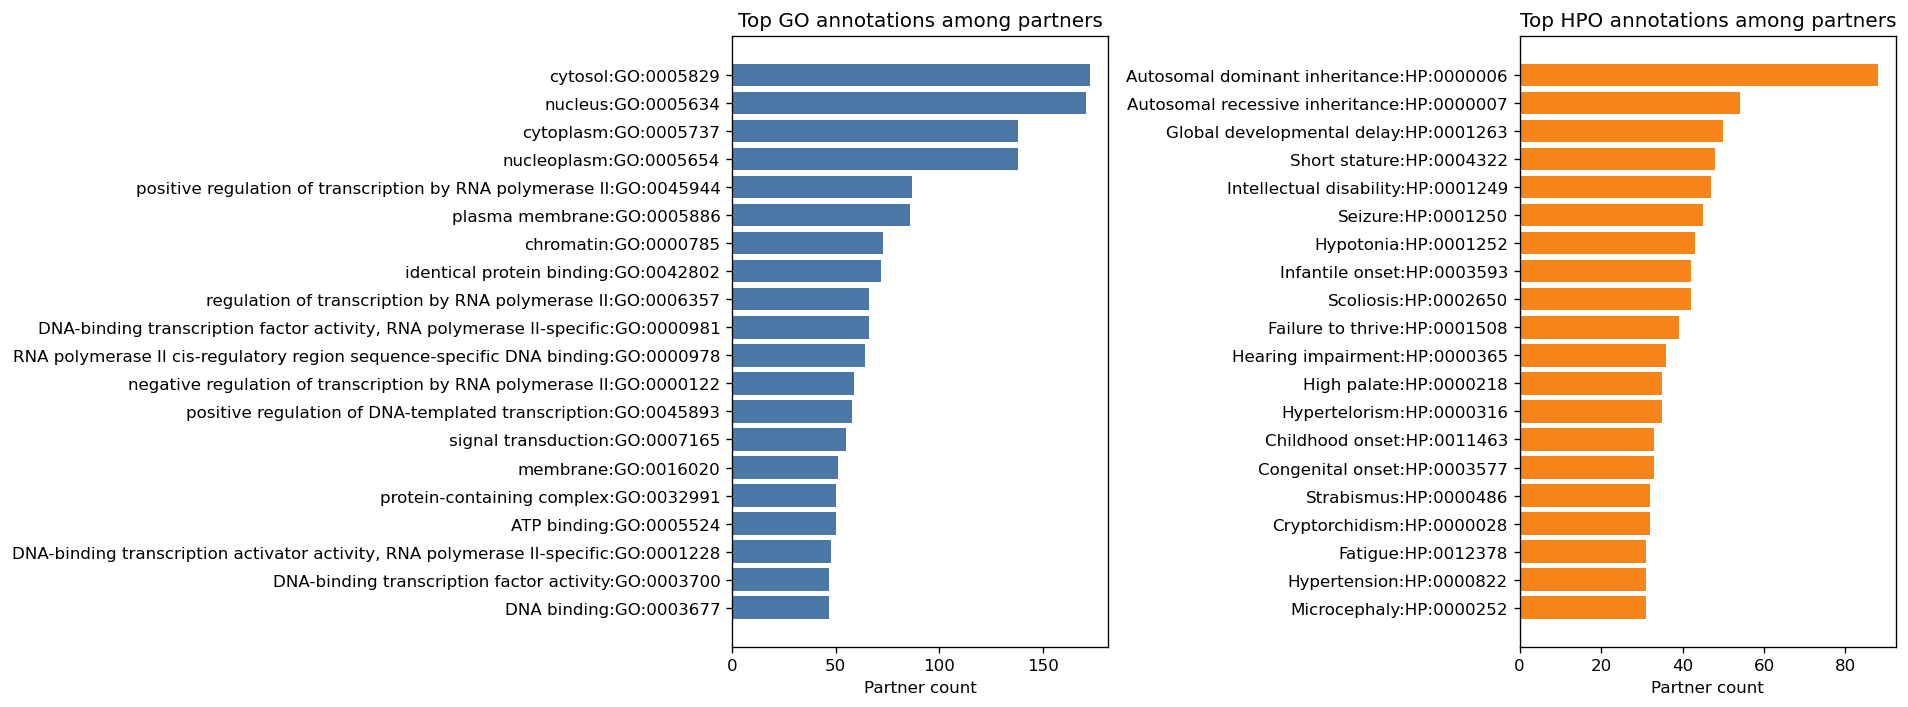

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

go_plot = top_go.reverse()
hp_plot = top_hp.reverse()

axes[0].barh(go_plot['term'].to_list(), go_plot['len'].to_list(), color='#4C78A8')
axes[0].set_title('Top GO annotations among partners')
axes[0].set_xlabel('Partner count')

axes[1].barh(hp_plot['term'].to_list(), hp_plot['len'].to_list(), color='#F58518')
axes[1].set_title('Top HPO annotations among partners')
axes[1].set_xlabel('Partner count')

plt.tight_layout()
plt.show()


## 5) Graph A: seed-centered interaction network

Edge color encodes sign summary from interaction flags:
- green: positive-only
- red: negative-only
- orange: mixed
- gray: unsigned/undirected

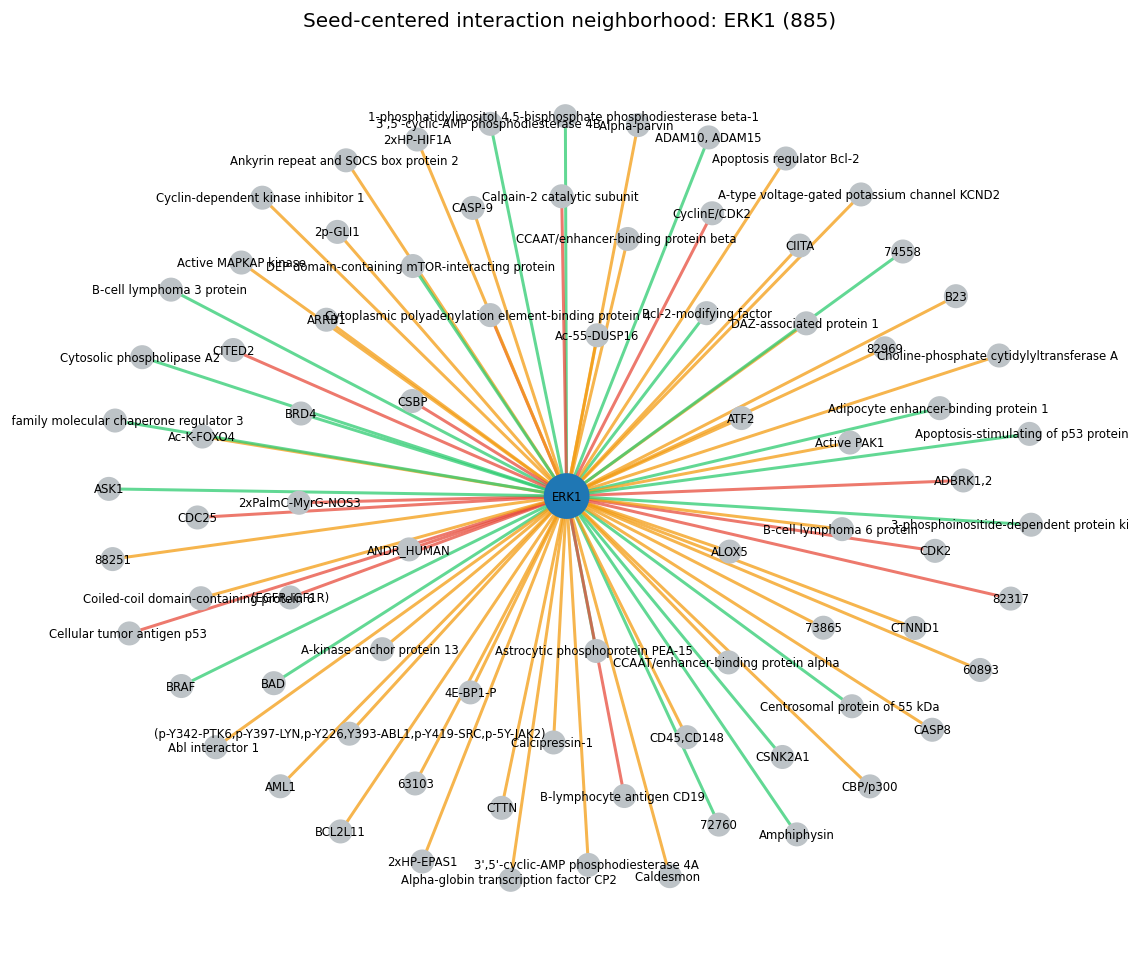

In [9]:
partner_name_map = {
    int(r['entity_id']): (r['names'][0] if r['names'] else str(r['entity_id']))
    for r in partners_df.select(['entity_id','names']).to_dicts()
}

G = nx.Graph()
G.add_node(seed_entity_id, label=seed_name, kind='seed')

for row in interactions_df.select(['member_a_id','member_b_id','has_positive_sign','has_negative_sign']).to_dicts():
    a, b = int(row['member_a_id']), int(row['member_b_id'])
    partner = b if a == seed_entity_id else a
    label = partner_name_map.get(partner, str(partner))

    if row['has_positive_sign'] and row['has_negative_sign']:
        color = '#f39c12'
    elif row['has_positive_sign']:
        color = '#2ecc71'
    elif row['has_negative_sign']:
        color = '#e74c3c'
    else:
        color = '#95a5a6'

    G.add_node(partner, label=label, kind='partner')
    G.add_edge(seed_entity_id, partner, color=color)

# Keep top-degree partners if very large
max_nodes = 80
if G.number_of_nodes() > max_nodes:
    # since this is a star-like graph, keep first partners by name
    keep_partners = sorted([n for n in G.nodes if n != seed_entity_id], key=lambda x: G.nodes[x]['label'])[:max_nodes-1]
    keep = {seed_entity_id, *keep_partners}
    G = G.subgraph(keep).copy()

pos = nx.spring_layout(G, seed=42, k=0.7)
edge_colors = [d['color'] for _, _, d in G.edges(data=True)]
node_colors = ['#1f77b4' if n == seed_entity_id else '#bdc3c7' for n in G.nodes]
node_sizes = [700 if n == seed_entity_id else 180 for n in G.nodes]

plt.figure(figsize=(12, 10))
nx.draw_networkx_edges(G, pos, edge_color=edge_colors, alpha=0.75, width=1.8)
nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=node_sizes)

labels = {n: G.nodes[n]['label'] for n in G.nodes}
nx.draw_networkx_labels(G, pos, labels=labels, font_size=7)
plt.title(f'Seed-centered interaction neighborhood: {seed_name} ({seed_entity_id})')
plt.axis('off')
plt.show()


## 6) Graph B: partner-to-annotation bipartite graph (top GO + HPO terms)

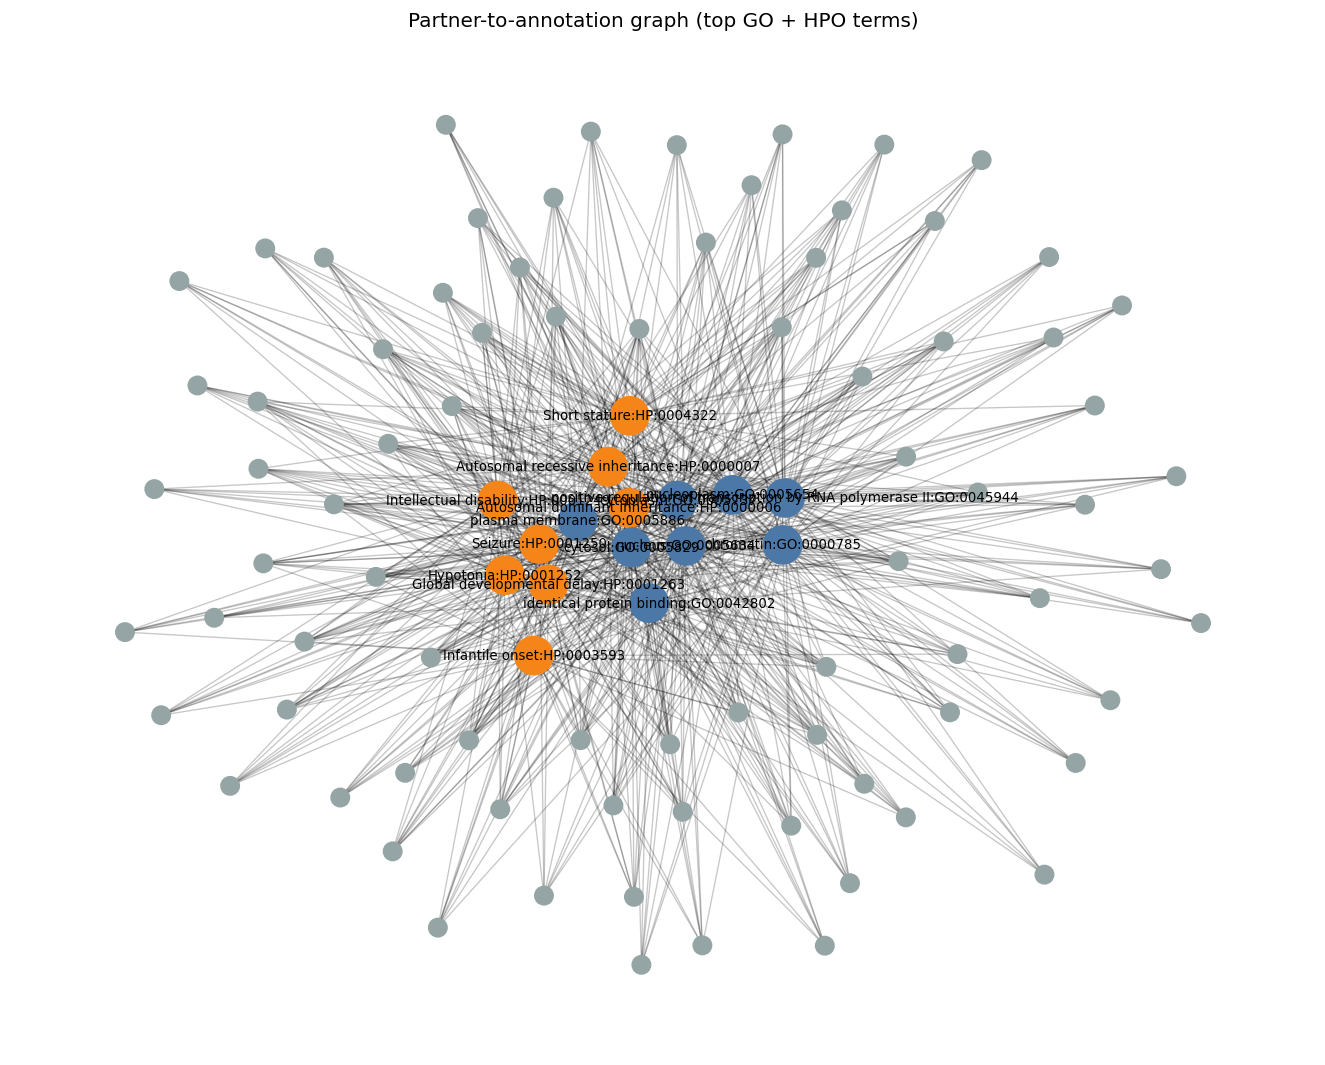

In [10]:
top_go_terms = set(top_go.head(8)['term'].to_list())
top_hp_terms = set(top_hp.head(8)['term'].to_list())

B = nx.Graph()

# Add term nodes
for t in top_go_terms:
    B.add_node(f'GO::{t}', label=t, kind='go')
for t in top_hp_terms:
    B.add_node(f'HP::{t}', label=t, kind='hp')

# Add partner nodes and edges to selected terms
for row in partners_df.select(['entity_id','names','cv_terms_go','cv_terms_hp']).to_dicts():
    pid = int(row['entity_id'])
    pname = row['names'][0] if row['names'] else str(pid)
    pnode = f'P::{pid}'
    B.add_node(pnode, label=pname, kind='partner')

    for t in (row.get('cv_terms_go') or []):
        if t in top_go_terms:
            B.add_edge(pnode, f'GO::{t}')
    for t in (row.get('cv_terms_hp') or []):
        if t in top_hp_terms:
            B.add_edge(pnode, f'HP::{t}')

# Keep only partners connected to at least one selected term
connected_partners = [n for n, d in B.nodes(data=True) if d['kind']=='partner' and B.degree(n) > 0]
term_nodes = [n for n, d in B.nodes(data=True) if d['kind'] in ('go','hp')]
B = B.subgraph(term_nodes + connected_partners).copy()

# Downsample if too dense
if len(connected_partners) > 80:
    keep_partners = sorted(connected_partners, key=lambda n: B.degree(n), reverse=True)[:80]
    B = B.subgraph(term_nodes + keep_partners).copy()

pos = nx.spring_layout(B, seed=17, k=0.45)

node_colors = []
node_sizes = []
for n, d in B.nodes(data=True):
    if d['kind'] == 'go':
        node_colors.append('#4C78A8'); node_sizes.append(520)
    elif d['kind'] == 'hp':
        node_colors.append('#F58518'); node_sizes.append(520)
    else:
        node_colors.append('#95a5a6'); node_sizes.append(120)

plt.figure(figsize=(14, 11))
nx.draw_networkx_edges(B, pos, alpha=0.22, width=0.8)
nx.draw_networkx_nodes(B, pos, node_color=node_colors, node_size=node_sizes)

labels = {
    n: d['label']
    for n, d in B.nodes(data=True)
    if d['kind'] in ('go', 'hp')
}
nx.draw_networkx_labels(B, pos, labels=labels, font_size=8)

plt.title('Partner-to-annotation graph (top GO + HPO terms)')
plt.axis('off')
plt.show()


## 7) Optional: add association context for partners

This fetches parent-member associations where partners are members, then summarizes parent types and role terms.

In [11]:
assoc_df = post_export('associations', {
    'query': '',
    'filters': {'member_entity_ids': partner_ids},
    'filename': f'seed_{seed_entity_id}_partner_associations'
})

display(assoc_df.group_by('parent_entity_type').len().sort('len', descending=True))
display(
    assoc_df
    .select(pl.col('association_annotation_terms').explode().alias('term'))
    .drop_nulls()
    .group_by('term').len()
    .sort('len', descending=True)
    .head(15)
)


[associations] exported rows: 2004


parent_entity_type,len
str,u32
"""reaction:OM:0015""",1066
"""complex:MI:0314""",913
"""protein family:OM:0010""",25


term,len
str,u32
"""reactant:OM:0310:OM:0310""",846
"""product:OM:0311:OM:0311""",396


## Interpretation template (fill in for your protein)

- Which GO compartments dominate partners?
- Which HPO phenotypes are over-represented among partners?
- Is sign balance mostly positive, negative, or mixed?
- Are partners mostly embedded in complexes, reactions, or pathways?
- Which sources dominate and could bias interpretation?

From here, you can iterate by adding ontology constraints (e.g., only `MI:0217` phosphorylation interactions, only `GO:0005634` partners, only `HP:0001250` partners, etc.).